Trying out different dimensionality reduction techniques....

Datasets:
 - manifold problem
 - fashion mnist
 - mnist

In [1]:
from sklearn.datasets import make_swiss_roll
import pickle, gzip
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist, fashion_mnist

In [2]:
from matplotlib.colors import ListedColormap
import numpy as np

In [3]:
# load the swiss roll data
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

In [4]:
# load the mnist and fashion mnist data...
(X_mnist, y_mnist), (_, _) = mnist.load_data()

# load the fashion mnist data
(X_fashion, y_fashion), (_,_) = fashion_mnist.load_data()

In [5]:
X_mnist.shape

(60000, 28, 28)

Visualisation.....

swiss roll data:.....

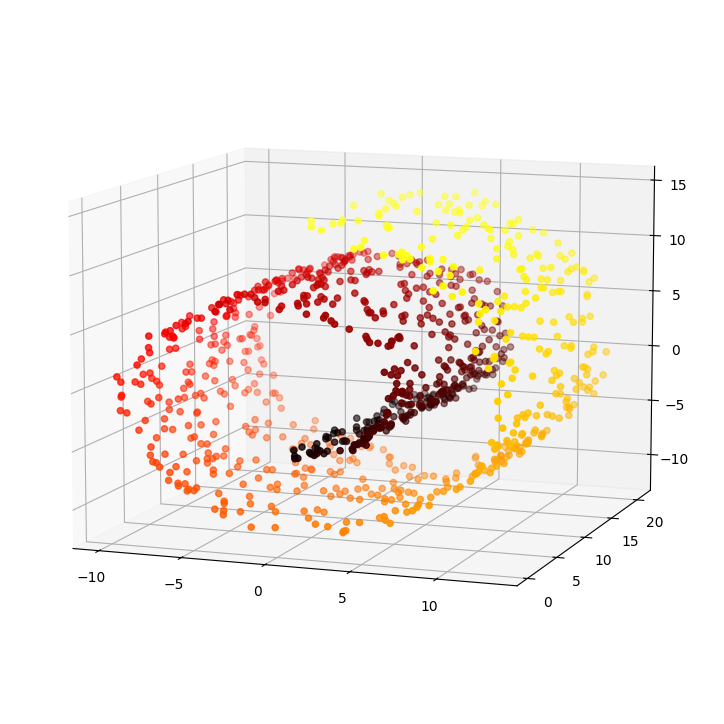

In [6]:
# visualising the swiss roll data....
darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(121, projection='3d')

ax1.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=t, cmap=darker_hot)
ax1.view_init(10, -70)
plt.show()

mnist:......

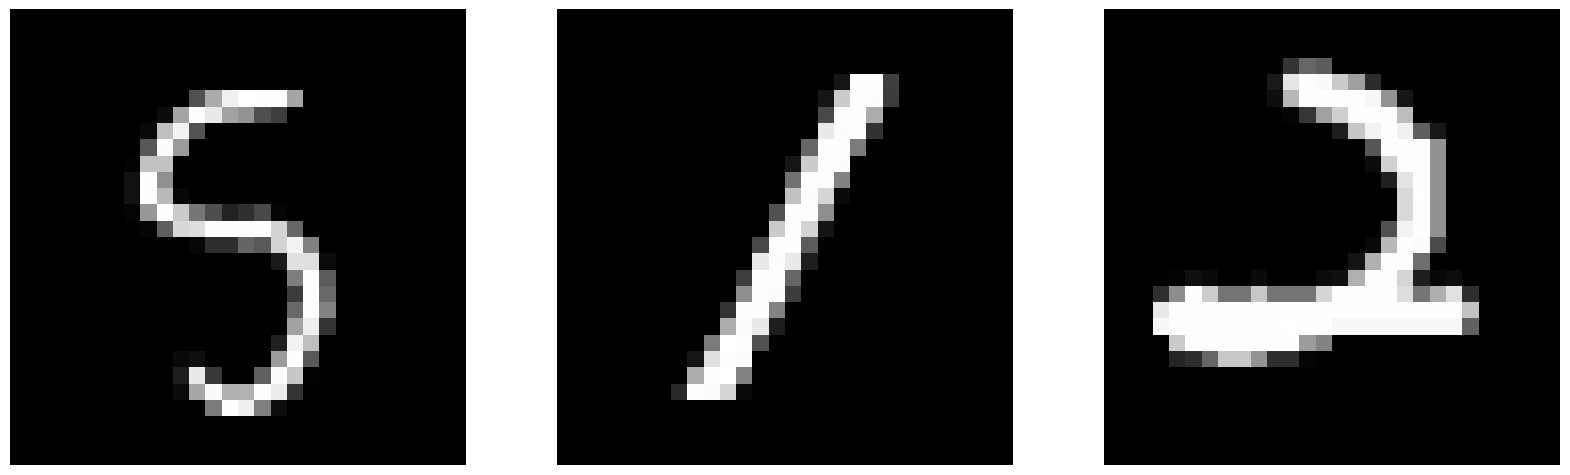

In [7]:
fig, ax = plt.subplots(1,3,figsize=(20,10))
for i in range(3):
    ax[i].imshow(X_mnist[np.random.choice(len(X_mnist), 1, replace=False).item()], cmap='gray')
    ax[i].axis('off')

fashion mnist:.........

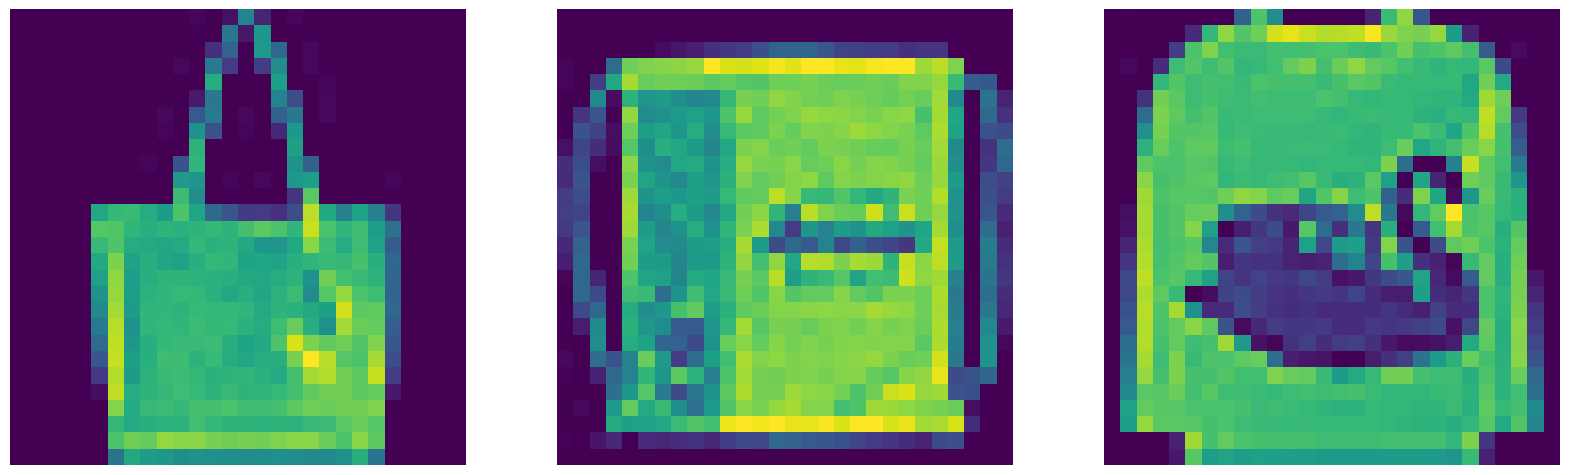

In [8]:
fig, ax = plt.subplots(1,3,figsize=(20,10))
for i in range(3):
    ax[i].imshow(X_fashion[np.random.choice(len(X_fashion), 1, replace=False).item()])
    ax[i].axis('off')

Thats the data................

PCA:

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [10]:
# doing the explained variance 
pca = PCA()
sc = StandardScaler()
pca.fit(sc.fit_transform(X_swiss))

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [11]:
pca.explained_variance_ratio_

array([0.38603589, 0.32653462, 0.28742949])

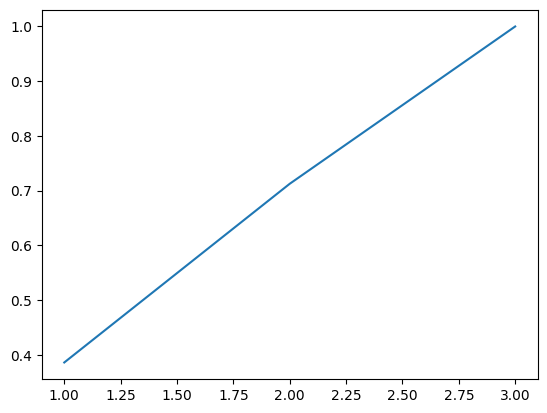

In [12]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(pca.explained_variance_ratio_))+1, np.cumsum(pca.explained_variance_ratio_))

slow rise in the explained variance above for each of the principal components clearly indicates that this is not a linear problem that can be resolved easily with PCA....

Trying PCA anyway:

In [13]:
pca = PCA(n_components = 2)
x_swiss_ = pca.fit_transform(X_swiss)

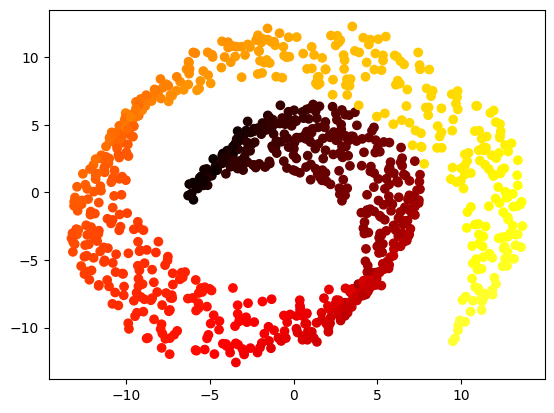

In [14]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_[:,0], x_swiss_[:,1], c=t, cmap=darker_hot)

as can be seen above pca doesn't fully grasp the change needed to have this unrolled in 2D...

PCA and the mnist dataset...

In [15]:
# converting to a proper shape
x_mnist_ = X_mnist.reshape(X_mnist.shape[0], -1)

In [16]:
x_mnist_.shape

(60000, 784)

In [17]:
# simple linearity check.....
pca = PCA()
sc = MinMaxScaler()
pca.fit(sc.fit_transform(x_mnist_))

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

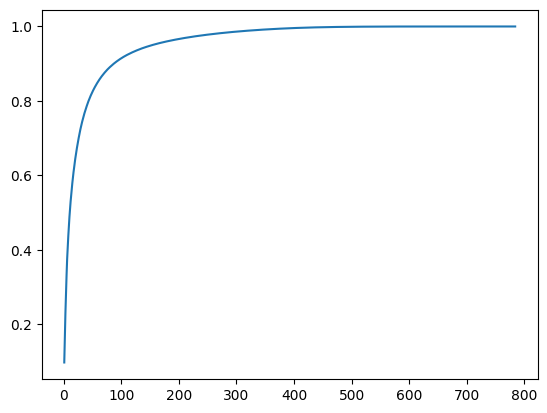

In [18]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(pca.explained_variance_ratio_))+1, np.cumsum(pca.explained_variance_ratio_))

this dataset is linear.... 43/784 components are required to explain 80% of the variance....as seen in the curve and in the computation below...PCA is therefore a good technique to use for this dataset..

In [19]:
np.argwhere(np.cumsum(pca.explained_variance_ratio_) > 0.8)[0]

array([43])

In [20]:
y_mnist.shape

(60000,)

In [21]:
# reducing the dimensionality with PCA...
pca = PCA(n_components=2)
sc = MinMaxScaler()
x_mnist_t = pca.fit_transform(sc.fit_transform(x_mnist_))

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow 

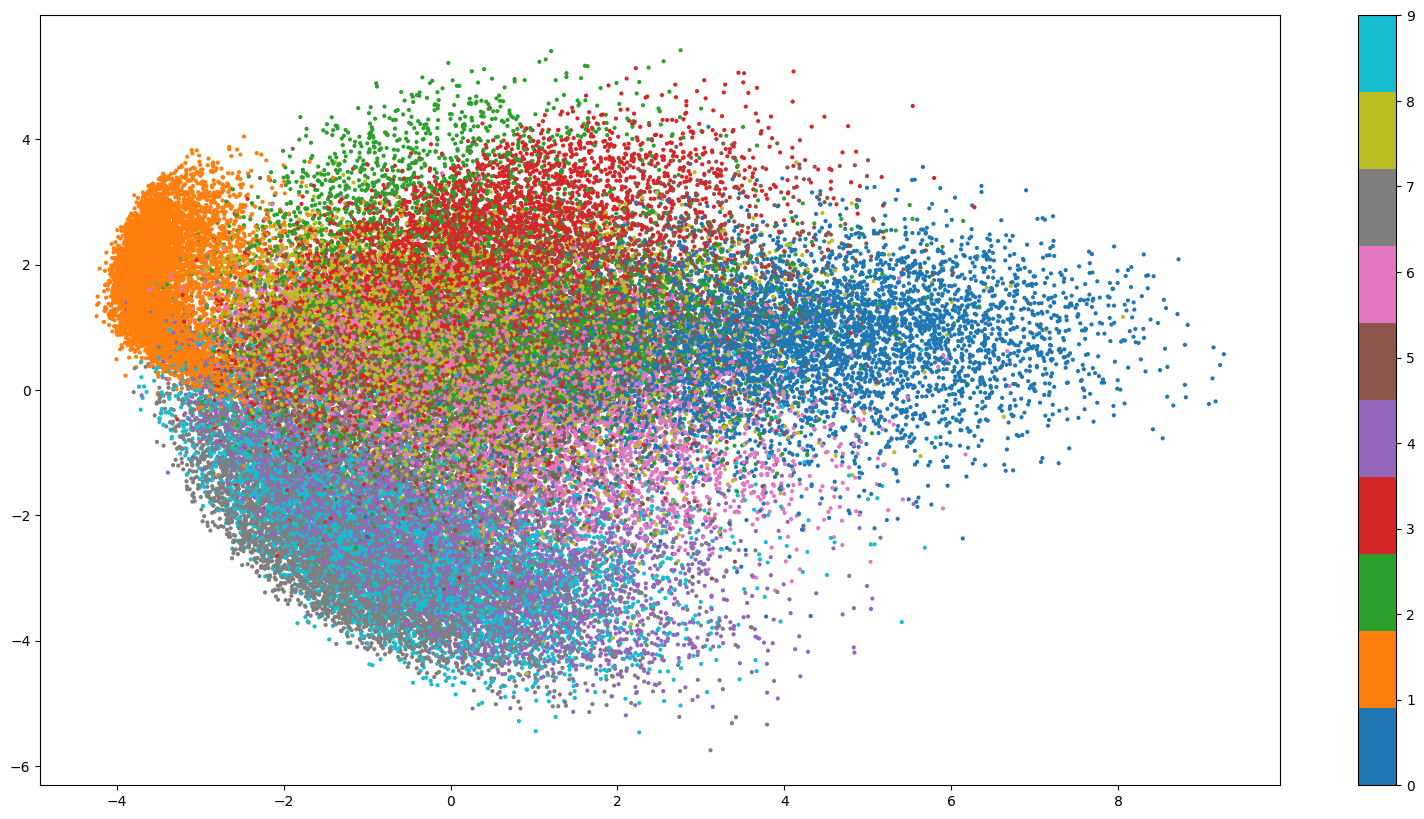

In [22]:
fig, ax = plt.subplots(figsize=(20,10))
f = ax.scatter(x_mnist_t[:,0], x_mnist_t[:, 1], c=y_mnist, cmap='tab10', s=4)
fig.colorbar(f, ax=ax)

pca for this problem not too good when we go low to 2 dimensions....starts mixing up points...probably performs better at higher dimensions... 

In [23]:
np.sum(pca.explained_variance_ratio_[:2])

np.float64(0.16799943970282122)

only 16% of the explainable variance with 2 principal components as in the above plot, hence explaining why the plot isn't that good....

getting 80% of the explainable variance with 44 points and reconstructing the images...

In [24]:
pca = PCA(n_components=43)
sc = MinMaxScaler()
x_scaled = sc.fit_transform(x_mnist_)
x_mnist_t = pca.fit_transform(x_scaled)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow 

In [25]:
sum(pca.explained_variance_ratio_)

np.float64(0.7992780218432819)

In [26]:
x_reconstructed = pca.inverse_transform(x_mnist_t)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_ + self.mean_


In [27]:
x_reconstructed = x_reconstructed.reshape(-1,28,28)

shows that with 43 compoments (80% of the variance) we can reconstruct the data... hence PCA is a good approach for this dataset..not for visualisation though...

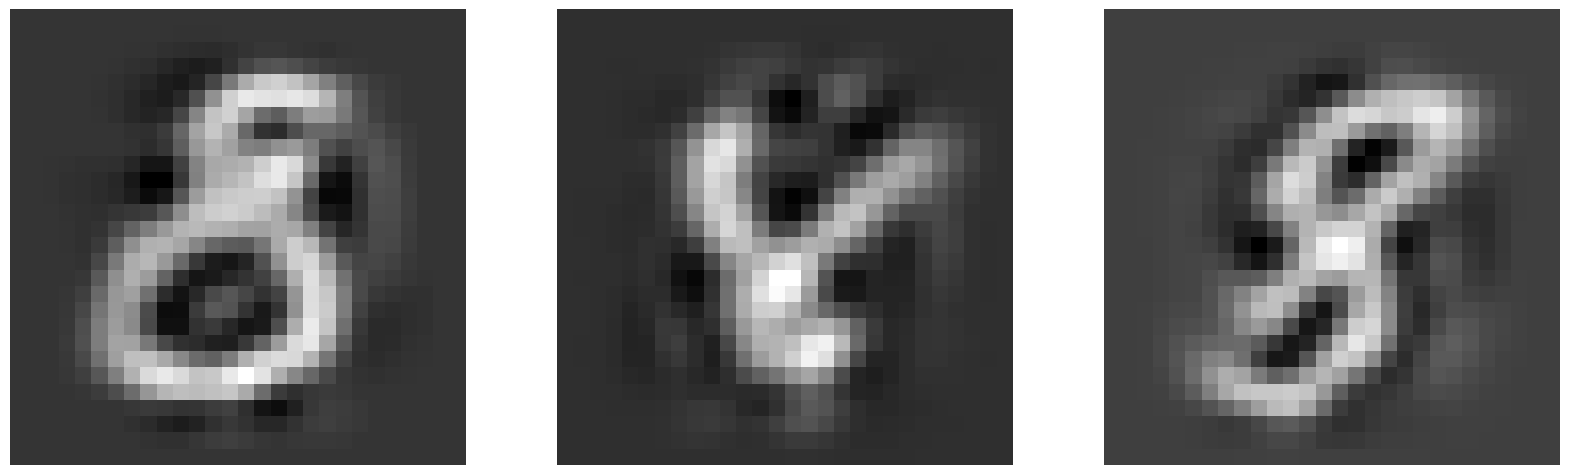

In [28]:
fig, ax = plt.subplots(1,3, figsize=(20,10))
for i in range(3):
    ax[i].imshow(x_reconstructed[np.random.choice(len(x_reconstructed), 1, replace=False).item()], cmap='gray')
    ax[i].axis('off')

what pca is doing....
- we are using 43 principal components in this case...each of them learning something about the data and then 
- multiplying these eigenvectors by the data to produce sums that show how much of each eigenvector is in a particular dimension..

visualising the learned eigenvectors from the data...

Each principal component is a direction (pattern) in the data that captures maximum remaining variance, and is orthogonal to the others.In the resulting transformed data. Each value is a projection (dot product) of the image onto that component. PCA doesn’t give you smaller images — it gives you coordinates in a new basis of global patterns, and each value is how strongly the image aligns with that pattern.

visualising some of the components

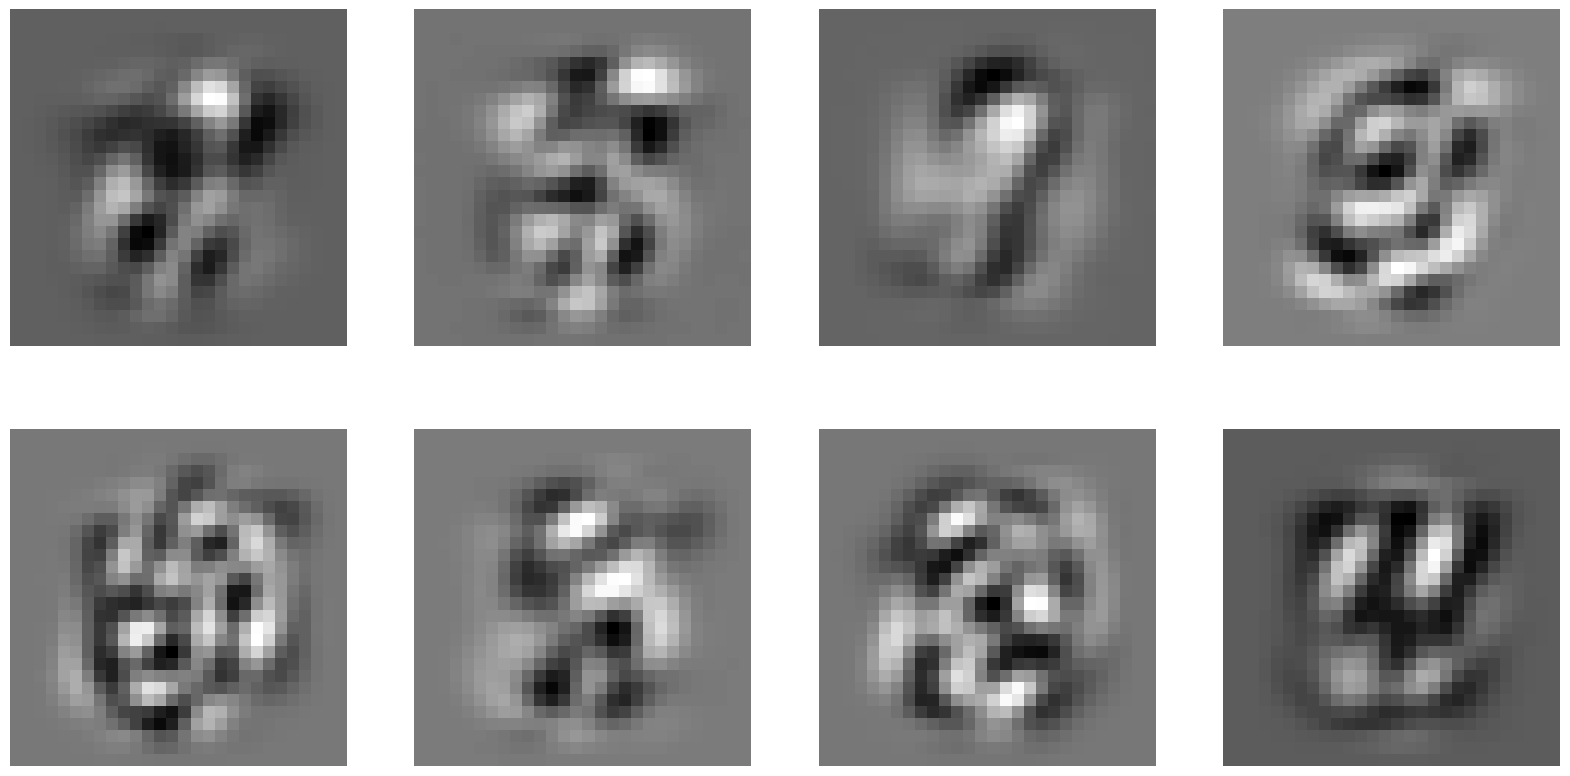

In [29]:
fig, ax = plt.subplots(2,4,figsize=(20,10))
for i in range(2):
    for j in range(4):
        ax[i,j].imshow(pca.components_[np.random.choice(len(pca.components_), 1, replace=False).item()].reshape(28,28), cmap='gray')
        ax[i,j].axis('off')

fashion mnist and PCA.....

In [30]:
X_fashion.shape

(60000, 28, 28)

In [31]:
pca = PCA()
ms = MinMaxScaler()
pca.fit(ms.fit_transform(X_fashion.reshape(X_fashion.shape[0],-1)))

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

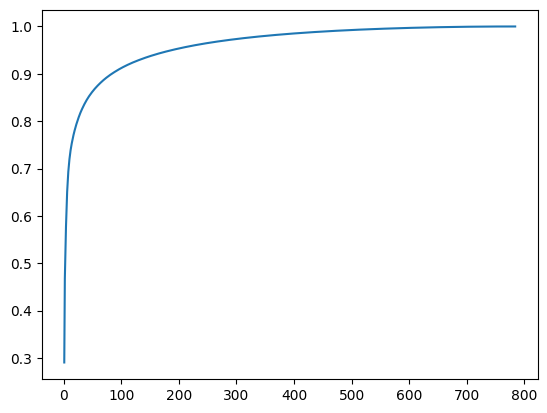

In [32]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(pca.explained_variance_ratio_))+1, np.cumsum(pca.explained_variance_ratio_))

In [33]:
np.argwhere(np.cumsum(pca.explained_variance_ratio_) > 0.8)[0]

array([23])

In [34]:
pca = PCA(n_components=3)
sc = MinMaxScaler()
x_scaled = sc.fit_transform(X_fashion.reshape(X_fashion.shape[0],-1))
x_fashion_t = pca.fit_transform(x_scaled)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow 

In [35]:
x_reconstructed = pca.inverse_transform(x_fashion_t)
x_reconstructed = x_reconstructed.reshape(-1,28,28)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_ + self.mean_
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/decomposition/_base.py:205: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_ + self.mean_


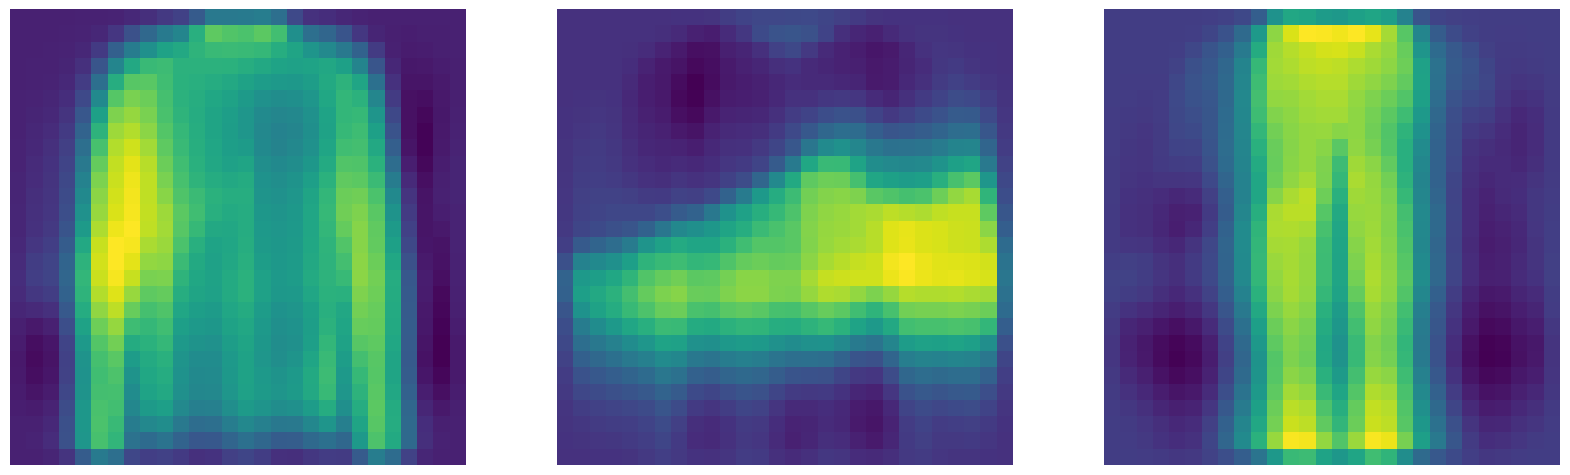

In [36]:
fig, ax = plt.subplots(1,3, figsize=(20,10))
for i in range(3):
    ax[i].imshow(x_reconstructed[np.random.choice(len(x_reconstructed), 1, replace=False).item()])
    ax[i].axis('off')

after 23 components ...out of the 784 total components we already have captured at least 80% of the explainable variance in the data showing the suitability of this dataset to the pca method as well for dim reduction..

In [37]:
x_fashion_t.shape

(60000, 3)

In [38]:
import plotly.express as px
import pandas as pd
import plotly.io as pio

In [39]:
# force browser rendering
pio.renderers.default = "browser"

In [40]:
df = pd.DataFrame({
    "PC1": x_fashion_t[:, 0],
    "PC2": x_fashion_t[:, 1],
    "PC3": x_fashion_t[:, 2],
    "label": y_fashion.astype(str)  # categorical
})

In [41]:
fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="label",
    opacity=0.7
)

fig.show()

pca does a fairly decent job at visualisation with 3 components...

**Multidimensional Scaling: MDS**
- core idea: construct an nxn matrix of pairwise distances - can use a wide range of distance computation methods.....
- generate a low-dimensional embedding representation that respects these distances.... (wit metric MDS, we produce a low dimensional embedding representation that respects the above distance matrix)
- downside, unlike pca, where we work on eigendecomposition of a (pxp) (features x features) covariance matrix, with MDS, we work on the decomposition (eigendecomposition with classic MDS, with metric MDS, optimize a closed form solution) of an (nxn) matrix - heavily dependent on the number of examples....

In [50]:
from sklearn.manifold import MDS

MDS with the swiss roll

In [ ]:
X_swiss.shape # only 1000 examples, so the 

(1000, 3)

In [78]:
mds = MDS(
    n_components = 2,
    metric_mds = True, # using metric MDS that preserves actual distance values, false means nonmetric MDS, preserves only rank of distances
    n_init = 5, # metric MDS is solved iteratively....
    metric='euclidean',
    init='classical_mds',
    normalized_stress=True
)

In [79]:
x_swiss_t = mds.fit_transform(X_swiss);

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 5
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero e

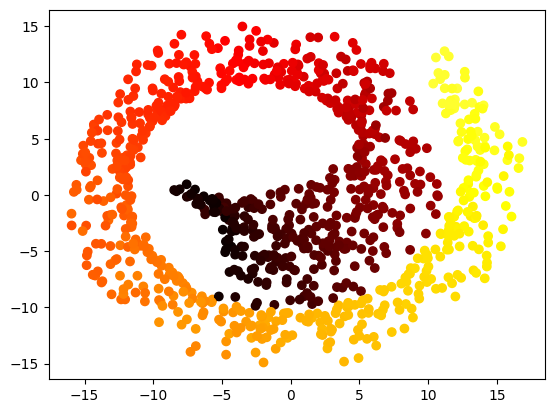

In [80]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

In [81]:
mds.stress_

np.float64(0.22128592187610227)

the above is the final stress after optimization:
- which is essentially the squared error between the original dissimilarities and the euclidean distances in the embedding
- lower = better
- chose to return the normalised stress instead of the raw stress values..
  - rough interpreation for normalised stress:
    - < 0.025 => excellent | < 0.05 => good | < 0.1 => fair | > 0.2 => poor

metric MDS asks:
- “Can I find 2D points whose Euclidean distances behave like those cosine dissimilarities?

perhaps using another precomputed distance like cosine would better unroll the manifold?

Big picture:
 - how the distance choice changes the embedding:
   - Euclidean/squared euclidean: preserve straight-line geometric separation; good when absolute magnitudes matter
   - Manhattan/city block: more robust to coordinate-wise deviations; often better when dimensions contribute additively. simply means manhayyan doesn't exagerrate the difference between two points when there's only a huge deviation say in one coordinate value
   - Cosine: ignores magnitudes, keeps direction/angle...useful when only profile shape matters
   - Correlation: like cosine after mean centering each vector; useful when u care about similarity of up/down patterns than level
   - Chebyshev: chebyshev distance metric only cares about the biggest difference across all features when computing the distance disimilarity between two points. everything else is ignored..
      - <img src="../../resource_images/Screenshot 2026-03-21 at 11.49.02.png"/>
      - <img src="../../resource_images/Screenshot 2026-03-21 at 11.52.23.png"/>
      - use chebyshev for mds when:
        - a single bad feature should dominate
        - you care about maximum tolerance violation
        - worst-case difference matters
      - Why it matters for MDS:
        - Points will only be far apart if any one feature differs a lot
        - many smaller differences won't matter
        - clusters amy form based on largest feature gaps...
      - Chebyshev distance: 2 points are far apart if they differ a lot in **any one** ferature - only the biggest difference counts.
   - Minkowski: a family that interpolates between manhattan and euclidean distances via p...
     - minkowski distance is just a general formula that includes both manhattan and euclidean as special cases. by changing the hyperparameter p, you control how strongly large coordinate differences dominate. 
     - <img src="../../resource_images/Screenshot 2026-03-21 at 12.00.15.png"/>
   - Mahalanobi:
     - accounts for feature covariance/scle; useful when axes are correlated or measured on different scales..
     - Mahalanobis distance fixes a major problem with euclidean distance:
       - euclidean distance treats each feature independently and equally - even if features are correlated or on very different scales..
       - Mahalanobis rescales and rotates the space so that:
         - correlated directions do not get double counted
         - large-variance directions do no dominate
         - comparisons are made in standardized covariance units
         - <img src="../../resource_images/Screenshot 2026-03-21 at 12.51.45.png"/>
         - why euclidean may sometimes fail:
           - 2 features: on different scales, the one with larger variance will dominate when using raw euclidean distances. Mahalanobis on the other hand, divides by variance and compares in standardized units - a fairer comparison.
         - Correlation problem:
           - suppose features are correlated: x1 ~ x2
           - so data lies along a diagonal line
             - Example:
               - A = (1,1) | B = (2,2) | C = (2,0)
             - Euclidean: A -> B ~ sqrt(2) | A -> C ~ sqrt(2)
             - So, euclidean says that B and C are equally far
             - But, in reality:
               - B follows the natural correlation direction
               - C is unusual (breaks correlation)
             - Mahalanobis:
               - Small distance along correlation direction
               - large distance perpendicular to it
             - So:
               - Mahalanobis (A,B) < Mahalanobis (A, C)
             - Geometric intuition:
               - Euclidean assumes spherical data
               - Mahalanobis adapts to elliptical data -> it stretches/compresses axes based on covariance
               - Use mahalanobis when:
                 - features are on different scales
                 - correlated features -> current & voltage | price & size | height & weight
               - Mahalanobis measures:
                 - how unusual is this point given the covariance
               - **Effect on MDS**
                 - If you use mahalanobis distances:
                   - MDS preserves **covariance-aware similarity**
                   - clusters reflect **statistical structure**
                   - correlated dimensions do not distort layout
                 - Compared to euclidean MDS:
                   - elongated clusters become more balanced and outliers become more clear
                 - Simple intuition:
                   - euclidean: measure distance with a ruler
                   - mahalanobis: measure distance after reshaping space to match data distribution
                 - **mahalanobis distance measures how far apart points are after correcting for feature scale and correlations, so differences along common/high-variance direvtions matter less, and unusual directions matter more**
   - Canberra / Bray-Curtis / Jensen-Shannon / Hamming / Jaccard / Dice / Yule / Russell-Rao / Rogers-Tanimoto / Sokal- / Kulczynski1*: specialized for sparse counts, binary features, compositional/probability data, or histogram-like data. SciPy’s pdist exposes many of these directly.
     - these distances exist because **euclidean style geeometry is often meaningless for:
       - sparse count vectors
       - binary presence/absence data
       - probability distributions
       - compositional data (parts of a whole)
     
     - Sparse count/non-negative numeric vectors:
       - These handle things like:
         - word counts | histogram bins | frequency tables | sparse signals
         - **Canberra distance:**
           - <img src="../../resource_images/Screenshot 2026-03-21 at 13.19.44.png"/>
            - So, Canberra:
              - emphasizes proportional change, especially near zero and is useful for:
                - sparse data | histogram bins | count vectors
         - **Bray-Curtis**
           - <img src="../../resource_images/Screenshot 2026-03-21 at 13.23.56.png"/>
         - **Probability distribution distances:**
           - used when vectors represent:
             - probabilities | normalised histograms | soft cluster assignments
             - Jensen-Shannon: based on KL divergence and works only on probability vectors
          - **Binary vector distances:**
             - these are 0/1 features like:
               - tags | presence/absence | item sets | boolean attributes
               - **Hamming:**
                - <img src="../../resource_images/Screenshot 2026-03-21 at 13.28.59.png"/>
               - **Jaccard:**
                - 
          


In [82]:
import numpy as np 
from scipy.spatial.distance import pdist, squareform

In [83]:
from sklearn.metrics import pairwise_distances

In [91]:
# euclidean distance
D = squareform(pdist(X_swiss, metric="euclidean"))
mds = MDS(
    n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds'
)

x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [92]:
mds.stress_

np.float64(0.22128592187610235)

using the cosine distance metric...

In [93]:
D = squareform(pdist(X_swiss, metric="cosine"))
mds = MDS(
    n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds'
)
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [94]:
mds.stress_

np.float64(0.21210726967960022)

a bit better with cosine distance actually....

In [99]:
D = pairwise_distances(X_swiss, metric='cosine')  # or any custom distance
mds =  MDS(n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds')
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py

In [100]:
mds.stress_

np.float64(0.21210726967960022)

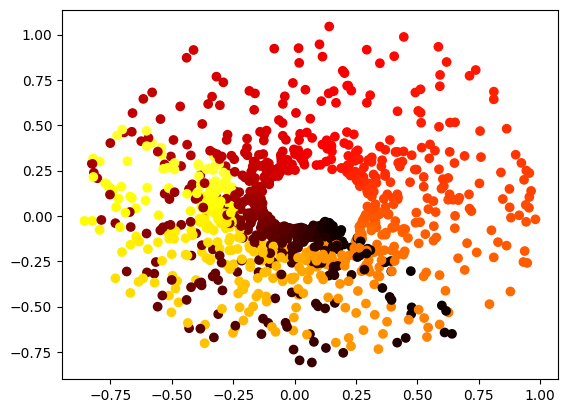

In [101]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

dooesn't unroll it well though in low dimensions leading to points overlapping...more of an aerial view though and you can see the general idea of it unrolling this data...

checking out squaredeuclidean distances....

In [102]:
D = pairwise_distances(X_swiss, metric='sqeuclidean')  # or any custom distance
mds = MDS(n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds')
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [104]:
mds.stress_ # much worse stress....

np.float64(0.31382738969935664)

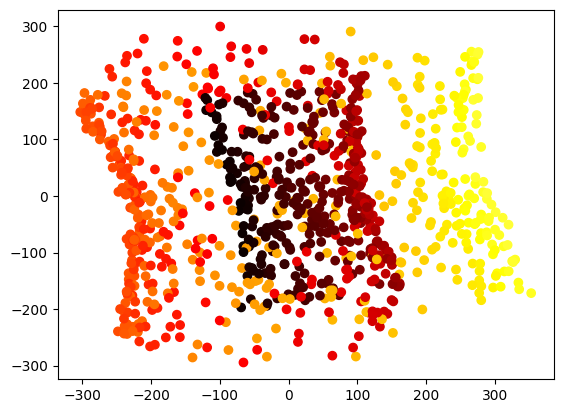

In [105]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

squared euclidean:
- used when you want to exaggerate large separations even more than euclidean
- impact on MDS is that:
  - far points become even farther
  - embedding may prioritise global separation over local structure...

Manhattan/City block:
- use when:
  - coordinate-wise deviation shouldd add linearly
  - you want less sensitivity to a few large coordinate gaps
- impact on MDS:
  - often gives embeddings less dominated by extreme differences
  - can preserve axis-aligned structure better than euclidean
- Manhattan distance treats each feature independently, so structures that are aligned with the coordinate axes tend to remain more faithful in the embedding
  - Euclidean rotates structure:
    - euclidean distance mixes dimensions together: so a difference along both axes simultaneously counts more strongly
    - <img src="../../resource_images/Screenshot 2026-03-21 at 15.25.08.png"/>
    - <img src="../../resource_images/Screenshot 2026-03-21 at 15.27.17.png"/>
- Manhattan sees the movement along different axes differently, whereas euclidean mixes the axes....
- Manhattan's often better when features are:
  - independent | additive | interpretable individually
- Examples: counts across categories | independent scores | feature wise deviations 

In [106]:
D = pairwise_distances(X_swiss, metric='cityblock')  # or any custom distance
mds = MDS(n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds')
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [107]:
mds.stress_

np.float64(0.24305232860779616)

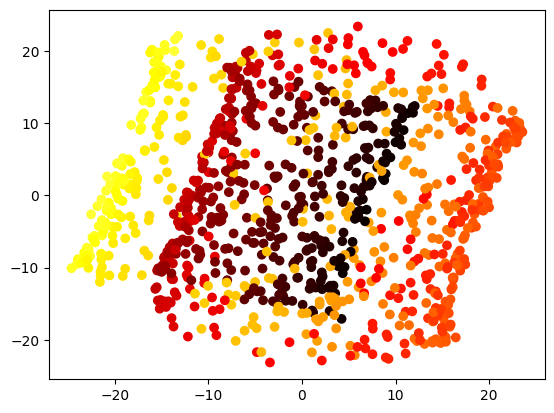

In [108]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

Minkowski:
 - p = 1 (Manhattan)
 - p = 2 (Euclidean)
- Use when you want to tune how strongly large coordinate differences are emphasized
- Impact on MDS:
  - Lower p spreads attention across many small differences
  - higher p puts more emphasis on the largest per-feature discrepancies

In [118]:
D = squareform(pdist(X_swiss, metric="minkowski", p=18))# or any custom distance
mds = MDS(n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds')
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

if it was the correlation precomputed distance being used here, you'd have to rescale it to a scale say 0 to 2, since we only expect distances when using precomputed... as can be seen above MDS struggles with the manifold in 2D...resulting in some points overlapping but u can see the big idea..tries to unroll it in an aerial visual way...

In [119]:
mds.stress_

np.float64(0.24951845386606328)

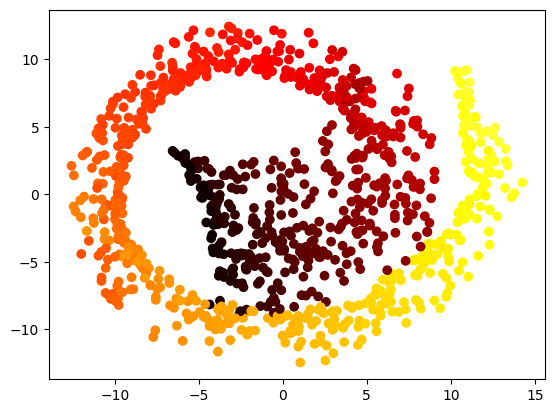

In [120]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

Cosine distance:
- magnitude should be ignored
- only orientation/profile shape matters
- common for text vectors, embeddings, tf-idf, high dimensional sparse data

- Impact on MDS:
  - vectors with similar direction but different lengths collapse together
  - clusters reflect pattern similarity, not raw size

Coorelation distance:
 - is closely related to cosine but effectluvely compares vectors after centering...so it cares about whether variables co-vary in the same pattern rather than whether raw vectors point in the same direction

In [121]:
D = squareform(pdist(X_swiss, metric="correlation"))# or any custom distance

# correlation values vary from -1 to 1, but MDS expects distances instead....so going to convert these to 0 to 2 scale by adding a 1 to the resultant matrix

D = D + 1

mds = MDS(n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds')
x_swiss_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [122]:
mds.stress_

np.float64(0.2037142078955656)

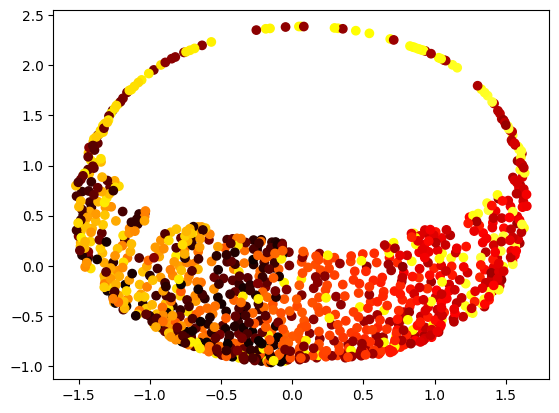

In [123]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

MDS and mnist and fashion mnist...

In [124]:
from sklearn.model_selection import train_test_split

In [138]:
# need to lower the size of this mnist set
x_mnist_d, _, y_mnist_d, _ = train_test_split(X_mnist, y_mnist, test_size=0.98, stratify=y_mnist)

cut them down to about 6000....

In [139]:
X_mnist.shape, x_mnist_d.shape

((60000, 28, 28), (1200, 28, 28))

In [146]:
# trying out euclidean distance mds on this mnist dataset
ms = MinMaxScaler()
z = ms.fit_transform(x_mnist_d.reshape(x_mnist_d.shape[0],-1))
D = squareform(pdist(z, metric="euclidean"))
mds = MDS(
    n_components=2,
    metric_mds=True,
    metric='precomputed',
    normalized_stress=True,
    init='classical_mds'
)
x_mnist_t = mds.fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/p

In [147]:
mds.stress_

np.float64(0.38018691159674967)

In [148]:
x_mnist_d.shape, y_mnist_d.shape

((1200, 28, 28), (1200,))

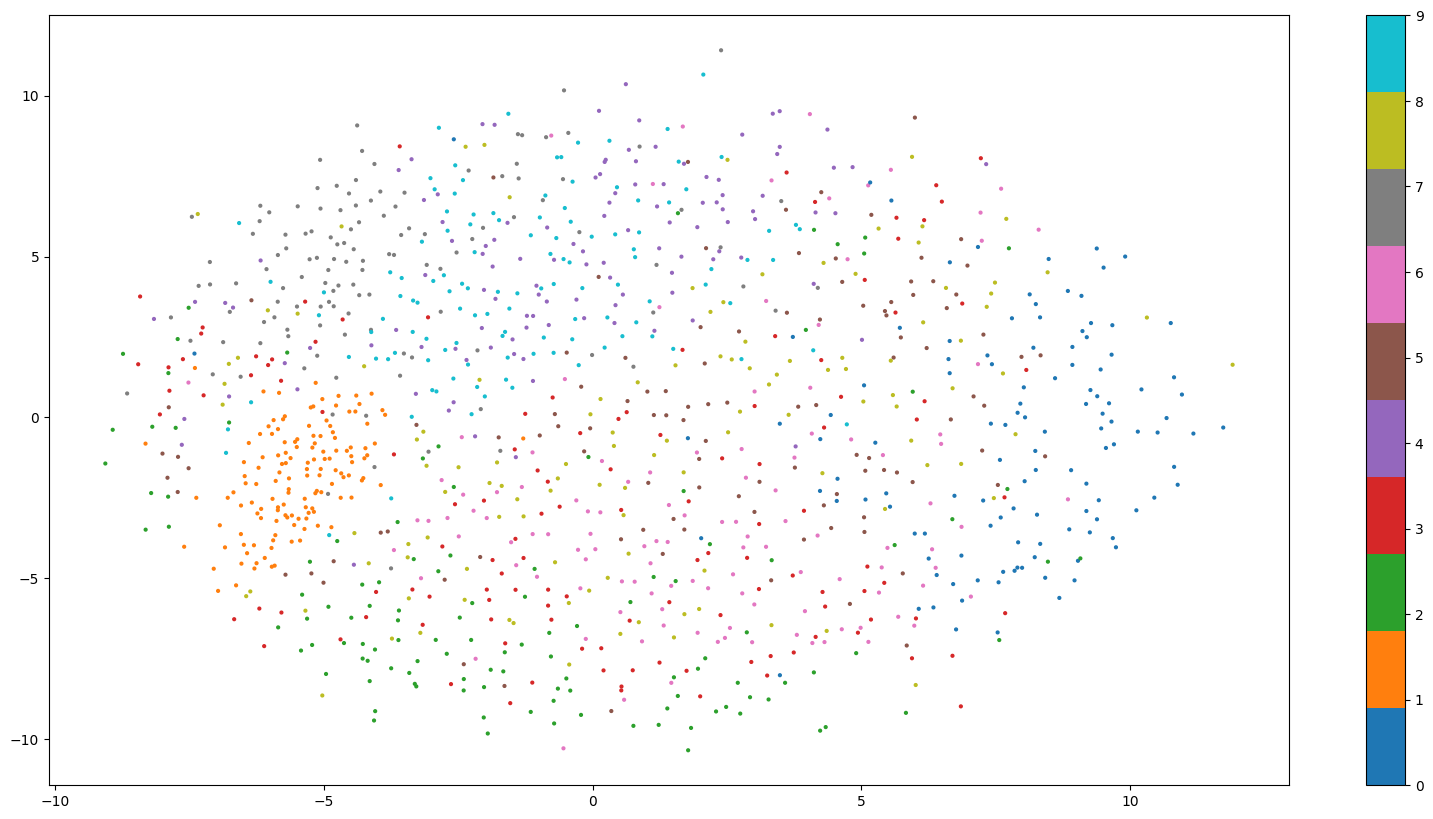

In [149]:
fig, ax = plt.subplots(figsize=(20,10))
f = ax.scatter(x_mnist_t[:,0], x_mnist_t[:, 1], c=y_mnist_d, cmap='tab10', s=4)
fig.colorbar(f, ax=ax)

moving on to isomap....

isomap:
 - compute the geodesic distances
 - then use mds to optimize the low dimensional embedding representation...

In [150]:
from sklearn.manifold import Isomap

isomap:
- number of neighbors: if too small => graph is sparse | geodesic paths are forced through very few routes | small amounts of noise or missing data can disconnect the graph entirely
- too large: run the risk of shortcuts - noise leading to wrong geodesic distances
- metric and p: what metric is used for neighbor construction: default is minkowski with p = 2, which is the euclidean distance
- isomap uses euclidean distance only for local hops | can change it to manhattan distance which is more robust to outliers in high dimensions | cosine distance which is better for text/sparse high dimensional data | or define and provide a custom distance
- path_method: How geodesic distances are computed:
  - 'auto'

In [151]:
iso = Isomap(
    n_neighbors=10,
    n_components=2,
    metric='minkowski',
    p = 2
)

In [152]:
x_swiss_t = iso.fit_transform(X_swiss)

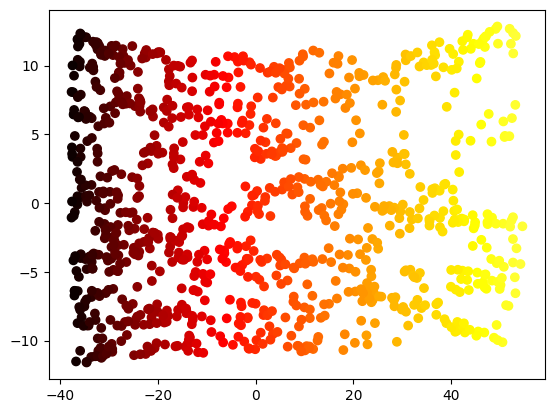

In [153]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

using a precomputed metric..

In [175]:
D = squareform(pdist(z, metric="cityblock"))
iso = Isomap(
    n_neighbors=10,
    n_components=2,
    metric='precomputed'
)
x_mnist_t = iso.fit_transform(D)

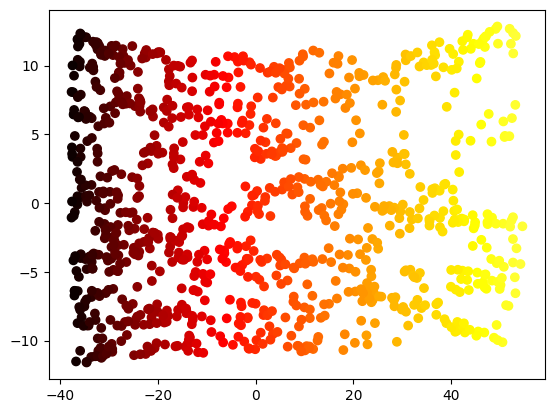

In [176]:
fig, ax = plt.subplots()
ax.scatter(x_swiss_t[:,0], x_swiss_t[:,1], c=t, cmap=darker_hot)

isomap with mnist...

In [177]:
iso = Isomap(
    n_neighbors=10,
    n_components=2,
    metric='minkowski',
    p = 2
)
ms = MinMaxScaler()
x_mnist_t = iso.fit_transform(ms.fit_transform(x_mnist_d.reshape(x_mnist_d.shape[0],-1)))

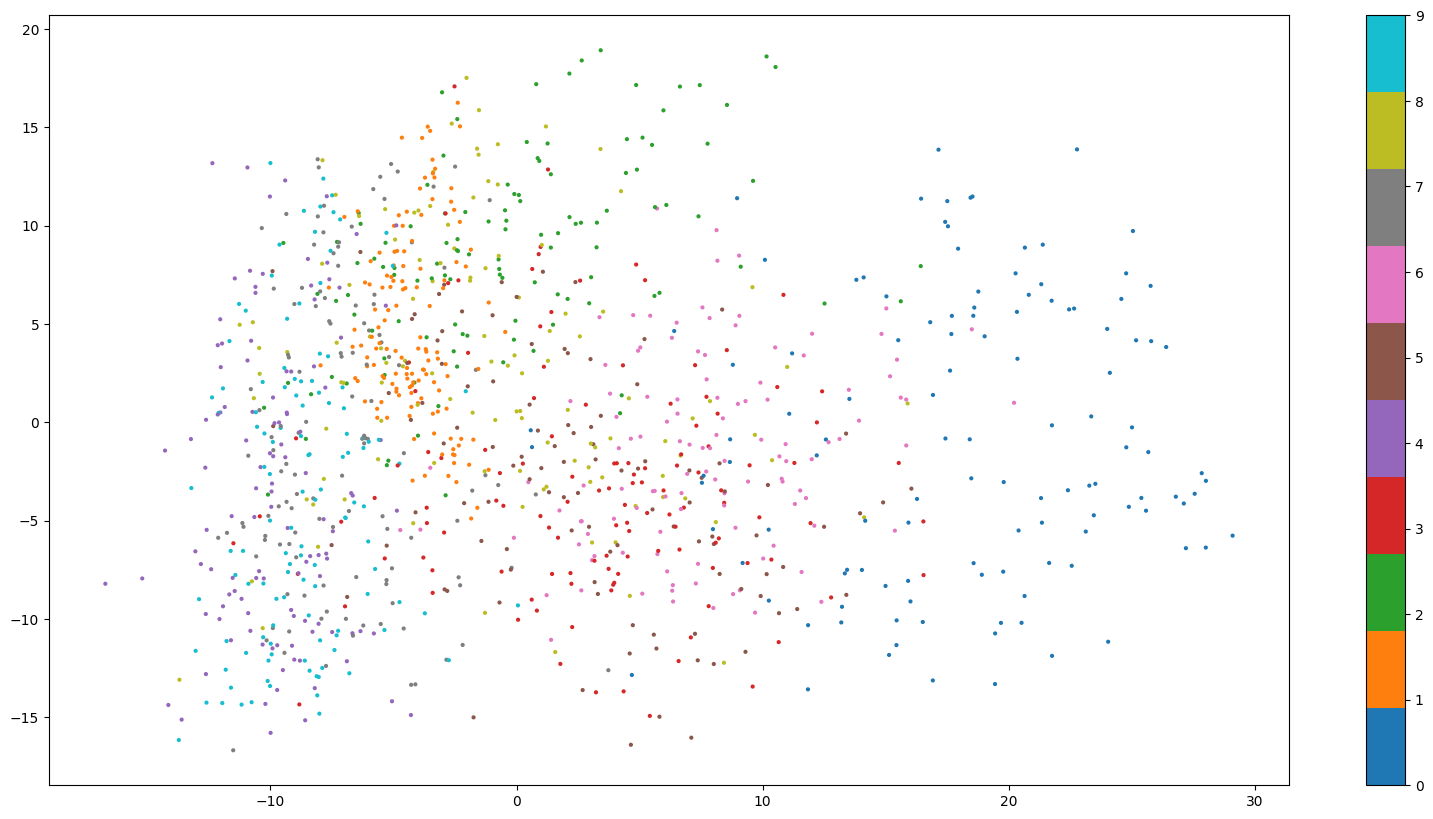

In [178]:
fig, ax = plt.subplots(figsize=(20,10))
f = ax.scatter(x_mnist_t[:,0], x_mnist_t[:, 1], c=y_mnist_d, cmap='tab10', s=4)
fig.colorbar(f, ax=ax)

just because the resultant 2d plot is poor doesn't mean isomap's terrible at decomposition..
- 2D might just be too small...

In [179]:
iso.reconstruction_error()

np.float64(105.15291850389295)

- above error is a measure of whether the embedding preserved the manifold geometry and is the primary metric for isomap. above reconstruction error is similar to mds stress metric...
- trustworthiness:
  - ignores global geometry
  - asks: did local neighbors remain neighbors
  - steps:
    - for each point, find k neighbors in the original space
    - find k neighbors in embedding
  - penalize points that became neighbors but shouldn't be
- residual variance:
  - almost the same idea as the reconstruction error, but expressed differently
  - it measures: (1 - R2(geodesic distances, embedding distances))
    - so it flattens both distance matrices
    - compute correlation
    - see how linear the relationship is
  - Interpretation:
    -  0 -> perfevt match
    -  1 -> completely unrelated

In [180]:
from sklearn.manifold import trustworthiness

In [181]:
trust = trustworthiness(ms.fit_transform(x_mnist_d.reshape(x_mnist_d.shape[0],-1)), x_mnist_t)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [182]:
trust

np.float64(0.7745851510067114)

that's stuff about isomap...
- essentially it is geodesic distances + MDS...

**Spectral Embedding:**
 - core idea:
    - compute the graph laplacian of the data -> nxn matrix which essentially represents and shows the connectivity (strucuture) and topology of the data... 
    - using eigendecomposition and only keeping the smallest eigenvectors which preserve the smoothness of the laplacian matrix -> reduce the dimensions..

In [183]:
from sklearn.manifold import SpectralEmbedding

sklearn api params:
- affinity:
  - how to build the initial similarity graph W. 
  - 'nearest_neighbors' => we build a binary graph (find neighbors or other points connected or not). Simpler, faster, and works well for clean cluster structure.. | so using nearest neighbors and then can also specify the n_neighbors to control the actual number of neighbors
  - 'rbf' => can also computed/produce an rbf weighted graph (less sparse than the nearest_neighbors one as all points within the nxn matrix will be populated). All points are connected with weights decaying by distance. captutes more nuanced similarity and is sensitive to gamma.

another approac

In [ ]:
se = SpectralEmbedding(
    n_com
)